In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("CAR_EVALUATION.csv")

print("Dataset shape:", df.shape)
print(df.head(15))

Dataset shape: (1728, 7)
   buying  maint doors persons lug_boot safety Target
0   vhigh  vhigh     2       2    small    low  unacc
1   vhigh  vhigh     2       2    small    med  unacc
2   vhigh  vhigh     2       2    small   high  unacc
3   vhigh  vhigh     2       2      med    low  unacc
4   vhigh  vhigh     2       2      med    med  unacc
5   vhigh  vhigh     2       2      med   high  unacc
6   vhigh  vhigh     2       2      big    low  unacc
7   vhigh  vhigh     2       2      big    med  unacc
8   vhigh  vhigh     2       2      big   high  unacc
9   vhigh  vhigh     2       4    small    low  unacc
10  vhigh  vhigh     2       4    small    med  unacc
11  vhigh  vhigh     2       4    small   high  unacc
12  vhigh  vhigh     2       4      med    low  unacc
13  vhigh  vhigh     2       4      med    med  unacc
14  vhigh  vhigh     2       4      med   high  unacc


In [11]:
# Convert original classes into binary classes
# good and vgood = Positive
# unacc and acc = Negative

df["Class"] = df["Target"].apply(
    lambda x: "Positive" if x in ["good", "vgood"] else "Negative"
)

features = [
    "buying",
    "maint",
    "doors",
    "persons",
    "lug_boot",
    "safety"
]

print(df[["Target", "Class"]].head(15))

print("\nClass distribution:")
print(df["Class"].value_counts())

   Target     Class
0   unacc  Negative
1   unacc  Negative
2   unacc  Negative
3   unacc  Negative
4   unacc  Negative
5   unacc  Negative
6   unacc  Negative
7   unacc  Negative
8   unacc  Negative
9   unacc  Negative
10  unacc  Negative
11  unacc  Negative
12  unacc  Negative
13  unacc  Negative
14  unacc  Negative

Class distribution:
Class
Negative    1594
Positive     134
Name: count, dtype: int64


In [12]:
# Select 15 mixed examples
# 8 positive + 7 negative

positive = df[df["Class"] == "Positive"]
negative = df[df["Class"] == "Negative"]

selected_rows = []

for i in range(8):
    selected_rows.append(positive.iloc[i])

for i in range(7):
    selected_rows.append(negative.iloc[i])

sample_df = pd.DataFrame(selected_rows)

# Shuffle them so positive and negative examples are mixed
sample_df = sample_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("Selected 15 examples:")
print(sample_df[["Target", "Class"] + features])

Selected 15 examples:
   Target     Class buying  maint doors persons lug_boot safety
0   unacc  Negative  vhigh  vhigh     2       2    small    med
1   unacc  Negative  vhigh  vhigh     2       2      med    low
2   vgood  Positive    med    med     2       4      big   high
3   unacc  Negative  vhigh  vhigh     2       2      med   high
4   vgood  Positive    med    med     4       4      med   high
5   unacc  Negative  vhigh  vhigh     2       2    small    low
6   vgood  Positive    med    med     3       4      big   high
7   vgood  Positive    med    med     2    more      big   high
8   unacc  Negative  vhigh  vhigh     2       2      big    low
9   vgood  Positive    med    med     3    more      big   high
10  vgood  Positive    med    med     4    more      med   high
11  unacc  Negative  vhigh  vhigh     2       2    small   high
12  unacc  Negative  vhigh  vhigh     2       2      med    med
13  vgood  Positive    med    med     3    more      med   high
14  vgood  Positiv

In [13]:
# Check whether a hypothesis covers an example
def covers(hypothesis, example):

    for h, x in zip(hypothesis, example):

        if h == "Ø":
            return False

        if h != "?" and h != x:
            return False

    return True


# Check whether h1 is more general than h2
def more_general_or_equal(h1, h2):

    for a, b in zip(h1, h2):

        if b == "Ø":
            continue

        if a != "?" and a != b:
            return False

    return True


# Generate minimal specializations of G
def minimal_specializations(hypothesis, example, domains):

    specializations = set()

    for i in range(len(hypothesis)):

        if hypothesis[i] == "?":

            for value in domains[features[i]]:

                if value != example[i]:

                    new_h = list(hypothesis)
                    new_h[i] = value

                    specializations.add(tuple(new_h))

    return specializations

In [14]:
# Possible values for every feature
domains = {
    feature: df[feature].unique().tolist()
    for feature in features
}

# Initial S and G
S = {
    tuple(["Ø"] * len(features))
}

G = {
    tuple(["?"] * len(features))
}

S_history = []
G_history = []

# Process the 15 selected examples
for _, row in sample_df.iterrows():

    example = tuple(row[feature] for feature in features)

    # ------------------------------------
    # POSITIVE EXAMPLE
    # ------------------------------------
    if row["Class"] == "Positive":

        # Remove G hypotheses that do not cover positive example
        G = {
            g for g in G
            if covers(g, example)
        }

        new_S = set()

        for s in S:

            if covers(s, example):
                new_S.add(s)

            else:

                h = list(s)

                for i in range(len(features)):

                    if s[i] == "Ø":
                        h[i] = example[i]

                    elif s[i] != example[i]:
                        h[i] = "?"

                h = tuple(h)

                if any(
                    more_general_or_equal(g, h)
                    for g in G
                ):
                    new_S.add(h)

        S = new_S

    # ------------------------------------
    # NEGATIVE EXAMPLE
    # ------------------------------------
    else:

        new_G = set()

        for g in G:

            if not covers(g, example):

                new_G.add(g)

            else:

                # Specialize G
                for i in range(len(features)):

                    if g[i] == "?":

                        for value in domains[features[i]]:

                            if value != example[i]:

                                h = list(g)
                                h[i] = value
                                h = tuple(h)

                                if any(
                                    more_general_or_equal(h, s)
                                    for s in S
                                ):
                                    new_G.add(h)

        G = new_G

    # Save S and G after this example
    S_history.append(S.copy())
    G_history.append(G.copy())

In [15]:
for i in range(15):

    print("\n" + "=" * 60)
    print("AFTER EXAMPLE", i + 1)
    print("=" * 60)

    print("Target:", sample_df.iloc[i]["Target"])
    print("Class :", sample_df.iloc[i]["Class"])

    print("\nS Boundary:")
    for s in S_history[i]:
        print(s)

    print("\nG Boundary:")
    for g in G_history[i]:
        print(g)


AFTER EXAMPLE 1
Target: unacc
Class : Negative

S Boundary:
('Ø', 'Ø', 'Ø', 'Ø', 'Ø', 'Ø')

G Boundary:
('?', 'high', '?', '?', '?', '?')
('high', '?', '?', '?', '?', '?')
('med', '?', '?', '?', '?', '?')
('low', '?', '?', '?', '?', '?')
('?', '?', '5more', '?', '?', '?')
('?', '?', '?', '?', '?', 'high')
('?', '?', '?', 'more', '?', '?')
('?', '?', '?', '?', 'big', '?')
('?', '?', '?', '?', '?', 'low')
('?', '?', '?', '4', '?', '?')
('?', 'low', '?', '?', '?', '?')
('?', 'med', '?', '?', '?', '?')
('?', '?', '3', '?', '?', '?')
('?', '?', '?', '?', 'med', '?')
('?', '?', '4', '?', '?', '?')

AFTER EXAMPLE 2
Target: unacc
Class : Negative

S Boundary:
('Ø', 'Ø', 'Ø', 'Ø', 'Ø', 'Ø')

G Boundary:
('high', '?', '?', '?', '?', '?')
('?', '?', '5more', '?', '?', '?')
('med', '?', '?', '?', '?', '?')
('?', 'med', '?', '?', 'med', '?')
('?', '?', '?', '?', 'small', 'low')
('?', 'low', '?', '?', '?', '?')
('?', '?', '4', '?', '?', 'low')
('?', '?', '?', '4', '?', 'low')
('low', '?', '?', '?',

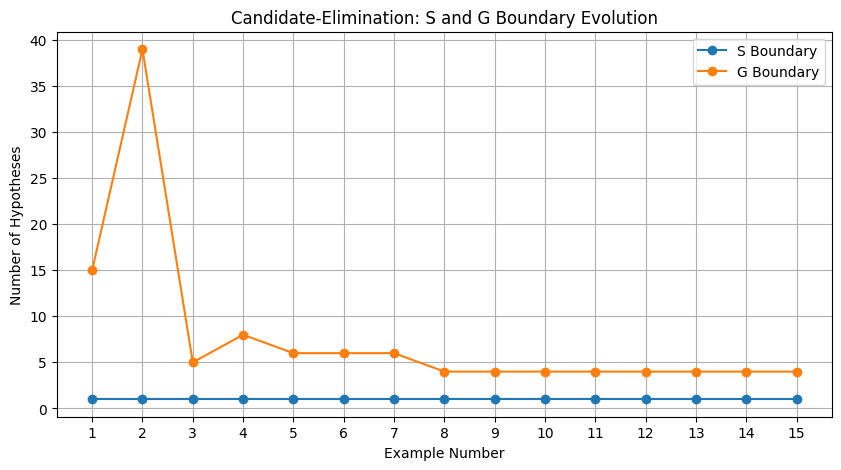

In [16]:
S_count = [len(s) for s in S_history]
G_count = [len(g) for g in G_history]

examples = range(1, 16)

plt.figure(figsize=(10, 5))

plt.plot(
    examples,
    S_count,
    marker="o",
    label="S Boundary"
)

plt.plot(
    examples,
    G_count,
    marker="o",
    label="G Boundary"
)

plt.xlabel("Example Number")
plt.ylabel("Number of Hypotheses")
plt.title("Candidate-Elimination: S and G Boundary Evolution")

plt.xticks(range(1, 16))
plt.legend()
plt.grid(True)

plt.show()


FINAL RESULT AFTER FIRST 15 EXAMPLES

Final S Boundary:
('med', 'med', '?', '?', '?', 'high')

Final G Boundary:
('?', 'med', '?', '?', '?', 'high')
('?', 'med', '?', '?', '?', '?')
('med', '?', '?', '?', '?', '?')
('med', '?', '?', '?', '?', 'high')

Number of S hypotheses: 1
Number of G hypotheses: 4


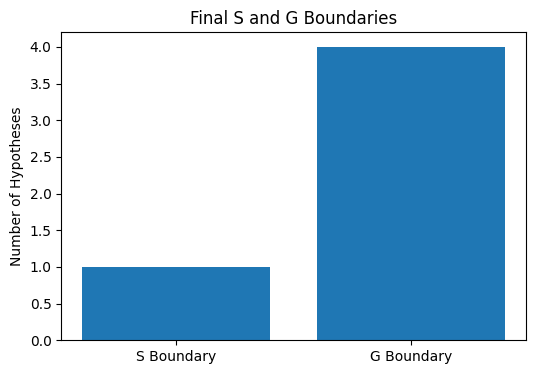

In [17]:
print("\n" + "=" * 60)
print("FINAL RESULT AFTER FIRST 15 EXAMPLES")
print("=" * 60)

print("\nFinal S Boundary:")
for s in S_history[-1]:
    print(s)

print("\nFinal G Boundary:")
for g in S_history[-1]:
    pass

for g in G_history[-1]:
    print(g)

print("\nNumber of S hypotheses:", len(S_history[-1]))
print("Number of G hypotheses:", len(G_history[-1]))


# Plot number of final hypotheses
plt.figure(figsize=(6, 4))

plt.bar(
    ["S Boundary", "G Boundary"],
    [
        len(S_history[-1]),
        len(G_history[-1])
    ]
)

plt.ylabel("Number of Hypotheses")
plt.title("Final S and G Boundaries")

plt.show()